In [49]:
%pip install kaggle

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [50]:
pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Users\Joshep\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# Pre-Diagnostico


## Entender el negocio


En esta seccion del notebook hablaremos de como **entender el negocio**, cuando hablamos de entender en negocion nos referimos a identificar la necesidad , actividad, decision y preguntas iniciales. En decir, daremos un contexto de los datos obtenidos y del objetivo al que deseamos llegar

### Contexto


La industria automotriz mundial está experimentando un cambio masivo hacia los vehículos eléctricos (EVs). Sin embargo, a pesar de los subsidios gubernamentales y las preocupaciones ambientales, muchos compradores potenciales dudan debido a la «ansiedad por la autonomía» (*Range Anxiety*): el temor a que un vehículo no tenga suficiente alcance para llegar a su destino y deje varados a sus ocupantes.

Este conjunto de datos ofrece una visión sintética e integral de 10.000 compradores potenciales de automóviles. Está diseñado para ayudar a los científicos de datos a analizar los factores demográficos, geográficos y psicológicos que influyen en la adopción de vehículos eléctricos y en la ansiedad por la autonomía.

## Entender los datos

Este conjunto de datos contiene 10.000 registros que reflejan distribuciones reales de compradores.

### Aspectos Destacados:
* **Demografía y geografía:** Edad, género, ingresos y tipo de ciudad (*Urban, Suburban, Rural*).
* **Hábitos de conducción e infraestructura:** Distancia del recorrido diario (*Daily Commute*), tipo de vehículo actual y disponibilidad de estaciones de carga en el hogar y el trabajo.
* **Factores psicológicos:** Nivel autopercibido de preocupación ambiental y nivel de ansiedad por la autonomía (*Range Anxiety Level*).
* **Variables objetivo:** 
  * Range_Anxiety_Level (Multiclase: *Low, Medium, High*)
  * Will_Buy_EV (Binario: *Yes/No*)
* **Realismo:** Se introdujo intencionalmente un pequeño porcentaje (~2%) de valores faltantes en ciertas columnas (*Income, Commute*) para que los principiantes practiquen técnicas de limpieza de datos e imputación (*Data Cleaning & Imputation*).

## Objetivo


### Predicción de Compra (Clasificación Binaria)
Predice si un cliente comprará un vehículo eléctrico (`Will_Buy_EV`) basándote en sus ingresos, la distancia de su recorrido diario y su acceso a infraestructura de carga.

# Conexion API kaggle

In [51]:
import kaggle

dataset_id = "itzzomkar/ev-adoption-behavior-and-range-anxiety"

kaggle.api.dataset_download_files(dataset_id, path="./datos", unzip=True)

print("El Dataset se descargo con exito en laa carpeta ./datos")

Dataset URL: https://www.kaggle.com/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety
El Dataset se descargo con exito en laa carpeta ./datos


## Cargar CSV

In [52]:
import os
print(os.listdir("./datos"))

['EV_Adoption_and_Range_Anxiety_Dataset.csv', 'noteboock.ipynb']


In [53]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")
df.head()

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


# Analisis descriptivo

## Preguntas Descriptivas

### 1.¿Cual es el nivel promedio de ansiedad?

In [54]:
frecuencia=df["Range_Anxiety_Level"].value_counts(dropna=False)
print(frecuencia)


Range_Anxiety_Level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64


el nivel promedio de ansiedad es *bajo* , esto quiere decir que los compradores se preocupan poco por la autonomia del vehiculo 

### 2.¿Cual es la edad promedio de los conductores?

In [55]:
promedio=df["Age"].mean()
vacios= df["Age"].isna().sum()
print(f"El promedio de edad es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de edad es 46.9362 
Hay 0 celdas vacias


El promedio de edad de los conductores es 47 años

### 3.¿Cual es la zona(Urbana, SubUrbana, Rural) con mas presencia de vehiculos electricos?

In [56]:
frecuencia=df["City_Type"].value_counts(dropna=False)
print(frecuencia)

City_Type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64


La zona con mayor presencia de vehiculos electricos es Urbana

### 4.¿Qué género comprar más vehículos eléctricos?

In [57]:
frecuencia=df["Gender"].value_counts(dropna=False)
print(frecuencia)

Gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64


El genero que mayormente compra vehículos eléctricos es el masculino

### 5.¿Qué distancia se reccorre diaramente en promedio con el vehículo?

In [58]:
total_celdas= df.size
promedio=df["Daily_Commute_km"].mean()
vacios= df["Daily_Commute_km"].isna().sum()
print(f"El promedio recorrido en km es {promedio} ")
print(f"Hay {vacios} celdas vacias")
print(f"celdas totales: {total_celdas} ")


El promedio recorrido en km es 41.10541806701294 
Hay 181 celdas vacias
celdas totales: 150000 


La distacia promedio reccorida diariamente en kilometros es de 41 km

### 6.¿Que carroceria se compra en promedio para este tipo de vehículos?

In [59]:
frecuencia=df["Current_Car_Type"].value_counts(dropna=False)
print(frecuencia)

Current_Car_Type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64


El promedio de carroceria de estos vehículos es Sedan

### 7.¿Que promedio de cargadores hay de camino a casa de los compradores?

In [60]:
promedio=df["Charging_Stations_Near_Home"].mean()
vacios= df["Charging_Stations_Near_Home"].isna().sum()
print(f"El promedio de cargadores de camino a casa es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino a casa es 5.3469 
Hay 0 celdas vacias


el promedio de cargadores de camino a casa de los compradores es de 5

### 8.¿Que promedio de cargadores hay de camino al trabajo de los compradores?

In [61]:
promedio=df["Charging_Stations_Near_Work"].mean()
vacios= df["Charging_Stations_Near_Work"].isna().sum()
print(f"El promedio de cargadores de camino al trabajo es {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de cargadores de camino al trabajo es 7.4582 
Hay 0 celdas vacias


El promedio de cargadores de camino al trabajo de los compradores es de 7

### 9.¿Que promedio de carros electricos tiene cada persona?

In [62]:
promedio=df["Number_of_Cars_Owned"].mean()
vacios= df["Number_of_Cars_Owned"].isna().sum()
print(f"El promedio de carros por persona {promedio} ")
print(f"Hay {vacios} celdas vacias")

El promedio de carros por persona 1.8599 
Hay 0 celdas vacias


El promedio de carros por comprador es de 2

### 10.¿Que promedio de personas compraron el vehículo con subsidio?

In [63]:
frecuencia=df["Subsidy_Available"].value_counts(dropna=False)
print(frecuencia)

Subsidy_Available
Yes    6008
No     3992
Name: count, dtype: int64


En promedio 6mil personas de cada 10mil reciben subsido para comprar vehículos electricos.

### 

# Comparaciones

## Ansiedad y genero

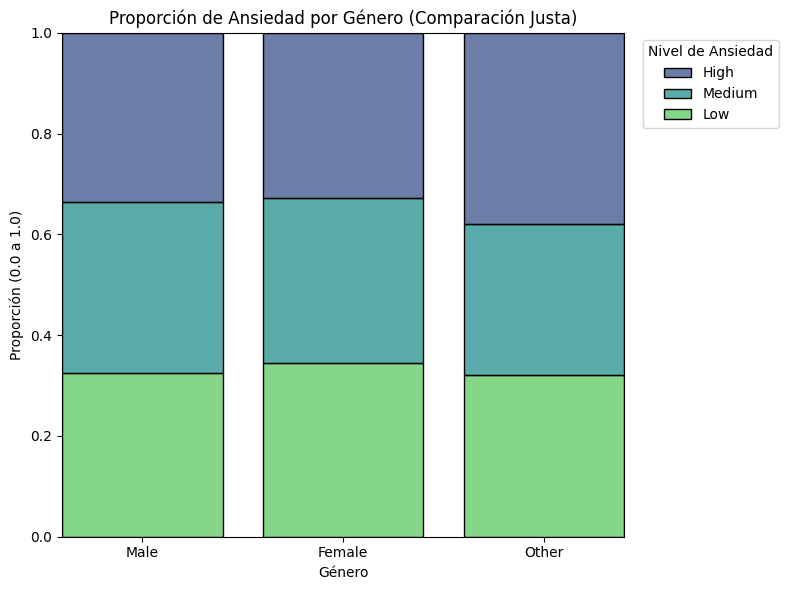

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(
    data=df,
    x="Gender",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],  
    multiple="fill",                     
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax
)


sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad")


plt.title("Proporción de Ansiedad por Género (Comparación Justa)")
plt.xlabel("Género")
plt.ylabel("Proporción (0.0 a 1.0)")

plt.tight_layout()
plt.show()

El análisis de proporciones relativas indica que el nivel de ansiedad por el rango de autonomía se distribuye de manera uniforme entre los distintos géneros analizados (Masculino, Femenino y Otro). En cada uno de los grupos, aproximadamente el 33% de los individuos presenta un nivel alto de ansiedad, un 33% un nivel medio y el 34% un nivel bajo. A nivel descriptivo, no se observan diferencias proporcionales significativas que sugieran una dependencia entre el género y la percepción de ansiedad.

## Ansiedad y Km diario recorrido

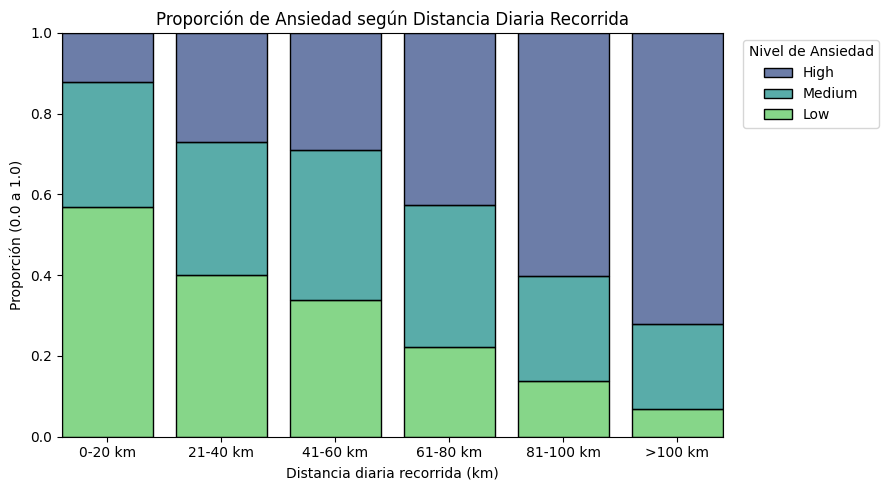

In [65]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("./datos/EV_Adoption_and_Range_Anxiety_Dataset.csv")

# 1. Agrupar la distancia continua en intervalos definidos (Bins)
bins = [0, 20, 40, 60, 80, 100, 140]
labels = ["0-20 km", "21-40 km", "41-60 km", "61-80 km", "81-100 km", ">100 km"]
df["Rango_Distancia"] = pd.cut(df["Daily_Commute_km"], bins=bins, labels=labels)

# 2. Graficar con los rangos definidos
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rango_Distancia",
    hue="Range_Anxiety_Level",
    hue_order=["High", "Medium", "Low"],
    multiple="fill",
    stat="percent",
    common_norm=False,
    palette="viridis",
    shrink=0.8,
    ax=ax,
)

# 3. Mover leyenda y corregir títulos
sns.move_legend(
    ax, "upper left", bbox_to_anchor=(1.02, 1), title="Nivel de Ansiedad"
)

plt.title("Proporción de Ansiedad según Distancia Diaria Recorrida")
plt.xlabel("Distancia diaria recorrida (km)")
plt.ylabel("Proporción (0.0 a 1.0)")
plt.tight_layout()
plt.show()

Se observa una fuerte relación positiva entre el kilometraje diario recorrido y el nivel de ansiedad por el rango de autonomía del vehículo eléctrico. Mientras que en trayectos cortos (0-20 km) predomina un nivel de ansiedad bajo (57%), el escenario se invierte de forma drástica al superar los 100 km diarios, donde la ansiedad alta pasa a dominar con más del 70% de los casos. Esto confirma que los recorridos de larga distancia son el principal factor determinante en la preocupación por la autonomía.